# **RAG**

Büyük Dil Modellerinin (LLM) cevap üretirken kendi başlangıç eğitim verileriyle
(şirketinizin özel PDF'leri veya veri tabanları) bilgi çekerek çok daha doğru ve güvenilir yanıtlar vermesini sağlayan bir sistemdir.

Bunu bir açık kitap sınavı gibi düşünebilirsiniz. Yapay zeka (öğrenci), soruyu cevaplarken sadece aklındakilere (pre-training) güvenmek yerine, sizin ona sunduğunuz devasa bir kütüphaneden (dış veri) ilgili kitapları bulur (Retrieval/Getirme), o sayfaları okur (Augmented/Zenginleştirme) ve size öyle cevap verir (Generation/Üretim).Bu sayede model uydurma (hallucination) yapmaz, güncel bilgilere erişebilir ve baştan eğitilmesine gerek kalmadan sizin özel belgeleriniz hakkında konuşabilir.

RAG, dış dünyadaki devasa veriyi modelin anlayabilmesi için geçici belleğe (Context Window) taşıma işlemidir. Bu taşıma işleminin son zamanlarda bu kadar başarılı olmasının sebebi ise geçici belleğin boyutunun inanılmaz derecede büyümesidir.

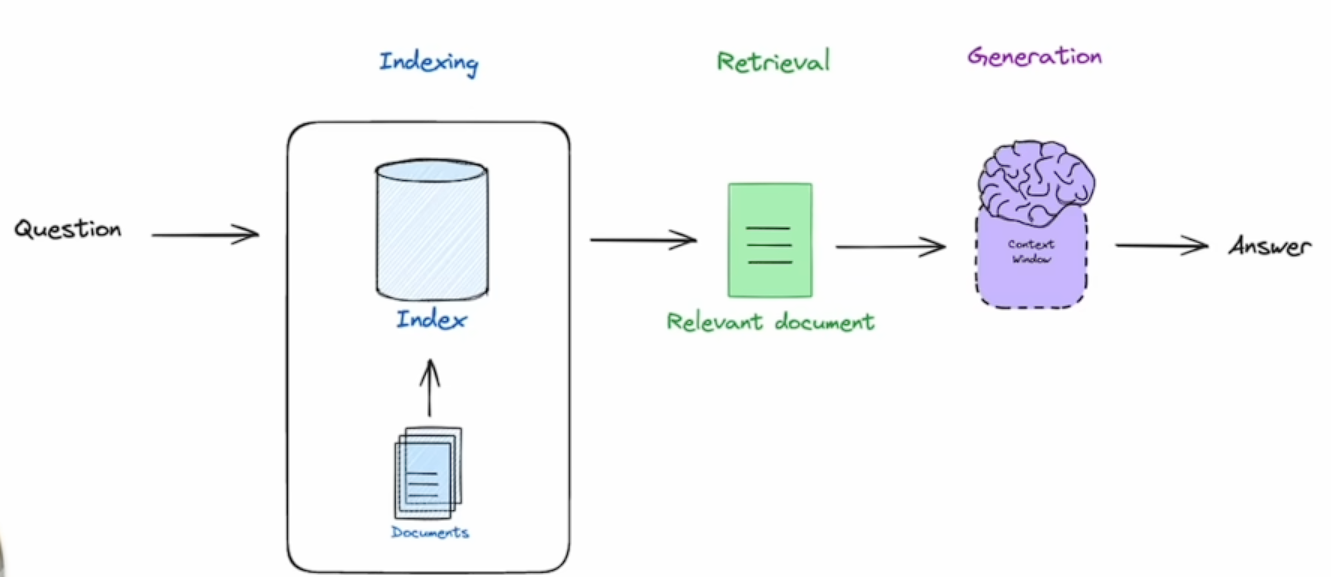

Bu görsel, RAG mimarisinin temel işleyişini uçtan uca özetleyen bir akış şemasıdır. Süreç, ham belgelerin (Documents) arama yapılabilecek yapılandırılmış bir veri tabanına (Index) dönüştürüldüğü İndeksleme (Indexing) adımıyla başlar. Kullanıcı bir soru (Question) sorduğunda, bu soru doğrudan modele gitmek yerine önce oluşturulan bu dizinde aranır ve sadece soruyla en alakalı bilgi parçaları (Relevant document) bulunur; bu aşama Geri Getirme (Retrieval) olarak adlandırılır. Son olarak Üretim (Generation) aşamasında, dış kaynaktan getirilen bu spesifik belgeler, yapay zeka modelinin (beyin simgesi ile gösterilen) "bağlam penceresine" (Context Window) aktarılır ve model sadece kendi ezberine güvenmek yerine bu taze verileri okuyarak çok daha doğru ve hedefe yönelik bir cevap (Answer) üretir.

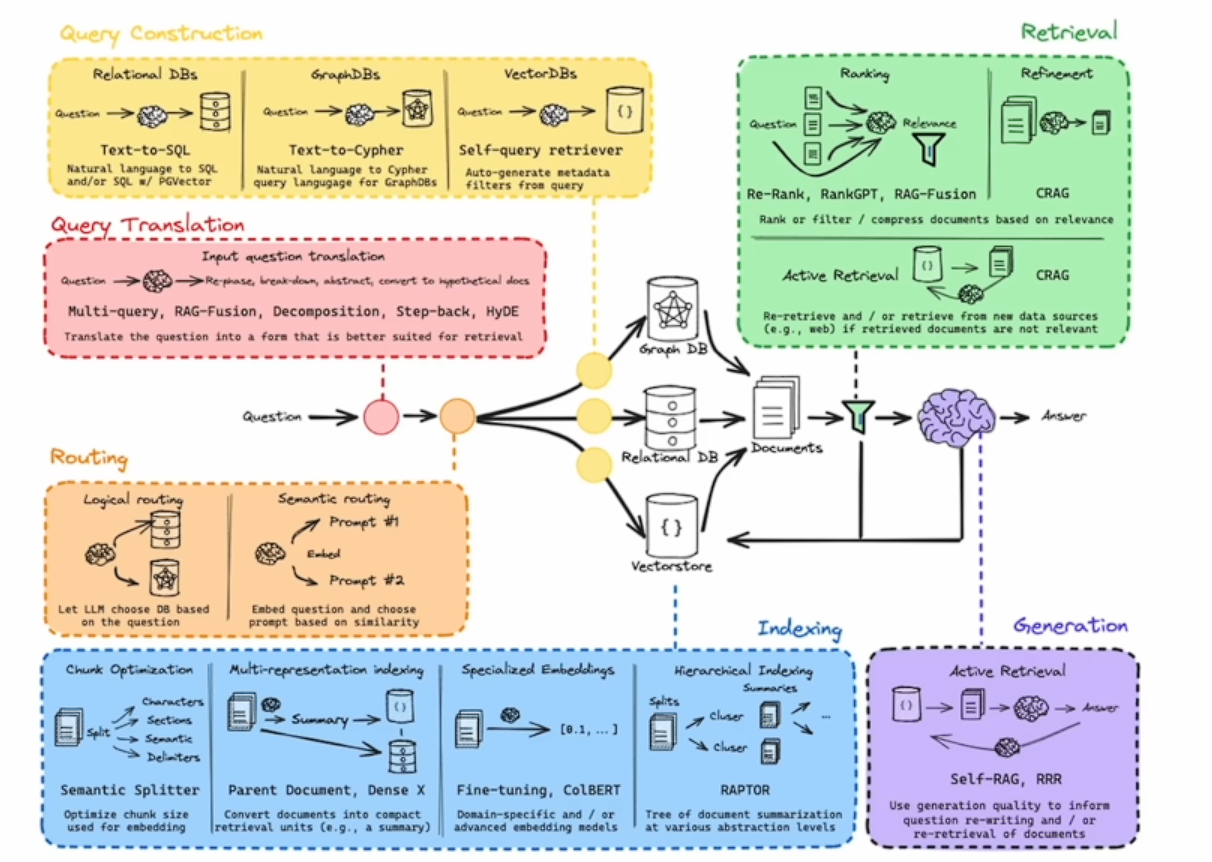

### **1. Query Translation (Sorgu Dönüştürme)**

Input question translation (Girdi sorusu dönüştürme):

Amacı, kullanıcının sorduğu ham, eksik veya karmaşık soruyu alıp; arama motorunun veya veri tabanının en kolay eşleşme bulabileceği, zenginleştirilmiş formata çevirmektir. Yani "Kullanıcı ne sordu?" sorusundan ziyade, "Ben bu soruyu veri tabanına nasıl sorarsam en iyi sonuçları koparırım?" diye düşünür.

İşte bu çeviri işlemini yaparken görselde listelenen 5 temel yöntemi kullanır:

1. Multi-query (Çoklu Sorgu):
İnsanların aynı şeyi ifade etmek için farklı kelimeler kullanabileceği gerçeğine dayanır. Yapay zeka, senin sorduğun tek bir soruyu alır ve aynı anlama gelen 3-4 farklı soru cümlesi üretir.

2. RAG-Fusion (Sorgu Füzyonu)
Multi-query yönteminin bir tık üstüdür. Üretilen o 3-4 farklı sorunun her biri için veri tabanında ayrı ayrı arama yapılır. Bu aramaların sonucunda onlarca belge gelir. RAG-Fusion algoritması bu belgeleri bir havuzda toplar, ortak olanları birleştirir (füzyon) ve en alakalılardan en alakasızlara doğru yepyeni bir "Süper Liste" oluşturur.Faydası ise birden fazla farklı aramanın gücünü birleştirerek, hiçbir kritik detayın gözden kaçmamasını sağlar.

3. Decomposition (Parçalara Ayırma)
Nasıl Çalışır: Bazen kullanıcılar "zincirleme" veya çok karmaşık sorular sorar. Sistem bunu tek seferde aratırsa kafası karışır. Bu yöntem, karmaşık soruyu çözülebilir alt adımlara böler.

>  Örnek: Soru: "Şirketin 2022'deki kar oranı, 2023'teki vergi borcunu nasıl etkiledi?"  
  1. "Şirketin 2022 kar oranı nedir?" (Arar ve bulur)   
  2. "Şirketin 2023 vergi borcu nedir?" (Arar ve bulur)
  
  Faydası ise adım adım ilerleyerek kompleks sorulara çok daha kesin ve mantıklı cevaplar üretilmesini sağlar.


4. Step-back (Geriye Adım Atma / Soyutlama)
Nasıl Çalışır: Bazen sorduğun soru o kadar spesifiktir ki, veri tabanı o dar alanda hiçbir şey bulamaz. Step-back, sorudan "bir adım geriye çıkarak" daha geniş, temel ilkeleri veya arka planı anlamaya yönelik daha genel bir soru üretir.

5. HyDE (Hypothetical Document Embeddings - Farazi Belge)
Nasıl Çalışır: Vektör veri tabanları "soru cümlesi" ile "cevap metnini" eşleştirmekte bazen zorlanır. Çünkü soru kelimeleri (nasıl, neden, ne zaman) ile belgedeki teknik terimler birbirine benzemez. HyDE tekniğinde yapay zekaya şu denir: "Bana bu soruya ait uydurma (farazi) bir cevap yaz." Yapay zeka soruyu cevaplar gibi bir taslak metin yazar. Sonra sistem, kullanıcının orijinal sorusunu çöpe atar ve veri tabanında arama yaparken bu "uydurma taslak cevabı" aratır.Faydası ise uydurma cevap ile gerçek belgeler yapısal olarak birbirine (kelime dağarcığı, jargon) çok daha fazla benzeyeceği için, sistem en doğru belgeyi şıp diye bulur.

### **2. Routing (Yönlendirme)**

Bu adım, işlenen sorunun hangi veritabanına veya şablona gönderileceğini belirleyen iki farklı "yönlendirme" yolunu açıklar.

Logical routing (Mantıksal yönlendirme): Bu yöntemde, karar verici doğrudan yapay zekanın (LLM) kendisidir. Görseldeki "Let LLM choose DB based on the question" (Soruya bağlı olarak veritabanını LLM'in seçmesine izin ver) yazısı bunu açıklar. Yapay zekaya, sistemde hangi veri tabanlarının bulunduğu ve içlerinde ne tür bilgiler olduğu önceden öğretilir. LLM soruyu okur, bir mantık yürütür ve soruyu doğru veri tabanına sevk eder.

 Örnek: * Kullanıcı sorusu: "Geçen ayki toplam satış gelirimiz ne kadar?"

LLM'in kararı: "Bu istatistiksel ve rakamsal bir soru. Metin tabanlı PDF'lerde aramak yerine bunu İlişkisel Veritabanına (SQL) göndermeliyim."

Faydası: Karmaşık kurallar yazmanıza gerek kalmaz; LLM, sorunun bağlamını anlayarak en mantıklı veri kaynağını bulur. Bu sayede alakasız veritabanlarında boşuna arama yapılmaz, sistem hızlanır.


Semantic routing (Anlamsal yönlendirme): Burada LLM'in mantık yürütmesinden ziyade matematiksel benzerlik kullanılır. Görseldeki "Embed question and choose prompt based on similarity" (Soruyu göm/vektöre çevir ve benzerliğe göre şablon seç) cümlesi bunu özetler. Kullanıcının sorusu sayılara (vektöre) dönüştürülür. Sistemde önceden hazırlanmış farklı iş akışları veya istem şablonları (Prompt #1, Prompt #2 vb.) vardır. Soru vektörü, hangi şablonun vektörüne matematiksel olarak daha yakınsa, soru doğrudan o yola girer.

Örnek: Şirketinize ait bir yapay zeka asistanı olduğunu düşünelim.

Soru 1: "Uygulamanız sürekli hata veriyor, paramı iade edin!" -> Sistem bu cümlenin anlamsal vektörünün "Şikayet/İade Şablonu"na çok benzediğini fark eder ve soruyu doğrudan teknik destek akışına yönlendirir.

Soru 2: "Yıllık üyelik ücretleriniz nelerdir?" -> Sistem bu cümlenin vektörünün "Satış/Fiyatlandırma Şablonu"na benzediğini anlar ve farklı bir prompt akışına yönlendirir.

Faydası: Logical Routing'e göre çok daha hızlıdır. Çünkü yapay zekanın "Acaba bu soru nereye ait?" diye düşünmesine gerek kalmaz; matematiksel benzerlik hesabı ile saliseler içinde soru ilgili şablona oturtulur. Sistemin amacından sapmasını engeller.

### **3.Query Construction**

Amacı, yönlendirme (Routing) aşamasından gelen doğal dildeki (insan dilindeki) soruyu, ilgili veri tabanının anlayabileceği makine veya sorgu diline çevirmektir. Sistemin "Tercüman" aşamasıdır.Görselde bu kutunun içinde verilerin tutulduğu 3 farklı veri tabanı tipine göre uygulanan yöntemler listelenmiştir:

1. Relational DBs (İlişkisel Veri Tabanları)
Kullanılan Yöntem (Text-to-SQL): Kurumsal verilerin (müşteri kayıtları, muhasebe kayıtları, stok durumları) büyük kısmı Excel tablolarına benzeyen ilişkisel veri tabanlarında tutulur. Görselde belirtilen "Natural language to SQL", İngilizce/Türkçe sorunun doğrudan SQL veritabanı diline çevrildiğini ifade eder.

Nasıl Çalışır: Sen sisteme "2023 yılında en çok ciro yapan 3 şubeyi getir" dersin. Yapay zeka bunu anlar ve arka planda SELECT branch_name FROM sales WHERE year=2023 ORDER BY revenue DESC LIMIT 3; şeklinde bir SQL kodu yazıp veri tabanına ateşler.

2. GraphDBs (Grafik Veri Tabanları)
Kullanılan Yöntem (Text-to-Cypher): Bazı veriler tablolar yerine bir ağ (network) haritası şeklinde tutulur. Şirket organizasyon şemaları, tedarik zincirleri veya finansal para transfer ağları buna örnektir. Görseldeki "Text-to-Cypher", sorunun bu ağlarda gezinmeyi sağlayan Cypher sorgu diline çevrildiğini gösterir.

Nasıl Çalışır: Sen "Ahmet'in müdürü, hangi projelerde Ayşe'nin ekibiyle ortak çalışıyor?" gibi kimin kime bağlı olduğunu gerektiren karmaşık bir soru sorarsın. Sistem bu soruyu alır, ağ üzerindeki düğümleri (kişiler) ve ilişkileri (çalışır, yönetir) takip edecek Cypher koduna dönüştürüp cevabı o karmaşık ağın içinden çekip çıkarır.

3. VectorDBs (Vektör Veri Tabanları)
Kullanılan Yöntem (Self-query retriever): PDF'lerin, sözleşmelerin veya uzun makalelerin tutulduğu bu veri tabanlarında bazen sadece "benzerlik" (anlam) araması yapmak yetmez; kesin kurallar koymak gerekir. Görseldeki "Auto-generate metadata filters from query" (Sorgudan otomatik meta veri filtreleri oluştur) tam olarak bunu yapar.

Nasıl Çalışır: Sen sisteme "Bana Mehmet Bey'in yazdığı, 2022 yılına ait gizlilik sözleşmelerini özetle" dersin. Sistem bu cümlenin içindeki kesin bilgileri cımbızla çeker. Anlamsal olarak sadece "gizlilik sözleşmesi" kısmını aratırken; arka planda Yazar = Mehmet Bey ve Yıl = 2022 şeklinde kesin filtreler uygular. Böylece 2023 yılında başkasının yazdığı bir sözleşme, anlam olarak çok benzese bile filtreye takılır ve senin önüne alakasız belge gelmesi (halüsinasyon) engellenir.

### **4.Indexing**

Amacı, ham ve karmaşık belgeleri yapay zekanın ve arama motorlarının ışık hızında bulabileceği, anlamlandırabileceği yapısal bir formata dönüştürmektir. Bu aşama sistemin "Kütüphanecisi" dir.Kırmızı, turuncu ve sarı kutulardaki işlemler sen soruyu sorduktan sonra anlık olarak gerçekleşir. Ancak Mavi Kutudaki işlemler sen soruyu sormadan çok daha önce, veriler sisteme ilk yüklendiğinde arka planda (offline olarak) yapılır. Yüz binlerce sayfalık PDF'i öylece veritabanına atamazsın; onları yapay zekanın midesine oturmayacak şekilde doğramalı ve etiketlemelisin.

Görselde bu kutunun içinde verilerin nasıl işlendiğine dair 4 farklı gelişmiş yöntem listelenmiştir:

1. Chunk Optimization (Parça Optimizasyonu)
Kullanılan Yöntem (Semantic Splitter): Yapay zekaya koca bir kitabı tek seferde yutturamazsın. Metinleri "chunk" adı verilen parçalara bölmen gerekir. Görseldeki “Optimize chunk size used for embedding” (Gömme için kullanılan parça boyutunu optimize et) cümlesi ve yanındaki "Karakterler, Bölümler, Anlamsal sınırlar" listesi bunu açıklar.

Nasıl Çalışır: Eski sistemler metni körlemesine, örneğin her 500 kelimede bir keserdi. Bu da bir cümlenin veya paragrafın tam ortadan ikiye bölünmesine, anlamın kaybolmasına yol açardı. Semantic Splitter (Anlamsal Bölücü) ise metni okur ve mantıklı yerlerden (örneğin bir bölüm bittiğinde veya konunun ana fikri değiştiğinde) böler.

Faydası: Yapay zeka arama yaptığında yarım yamalak cümleler değil, başı sonu belli, bağlamı kopmamış anlamlı paragraflar bulur.

2. Multi-representation Indexing (Çoklu Gösterim İndeksleme)
Kullanılan Yöntem (Parent Document, Dense X): Görseldeki “Convert documents into compact retrieval units (e.g., a summary)” (Belgeleri özet gibi kompakt arama birimlerine dönüştür) cümlesi bu mantığı özetler.

Nasıl Çalışır: 50 sayfalık bir sözleşmeyi aratmak çok yavaştır. Sistem bu uzun belgeyi (Parent Document / Ana Belge) veritabanının bir köşesine koyar ama arama motoruna bu belgenin kısa bir özetini (Summary) sunar. Sen soru sorduğunda, sistem devasa metinler içinde boğulmak yerine sadece özetleri okuyarak tarama yapar.

Faydası: Tıpkı bir kütüphanede kitabın tamamını okumak yerine arka kapağındaki özete bakarak aradığın kitap olup olmadığını anlamak gibidir. Eşleşme bulunursa, sistem gidip ana belgenin tamamını senin için getirir. İnanılmaz bir hız kazandırır.

3. Specialized Embeddings (Özelleştirilmiş Vektör Modelleri)
Kullanılan Yöntem (Fine-tuning, ColBERT): Görseldeki “Domain-specific and / or advanced embedding models” (Alana özgü ve/veya gelişmiş gömme modelleri) cümlesine dayanır. "Embedding", kelimelerin makine için sayılara ([0.1, 0.5, ...]) dönüştürülmesidir.

Nasıl Çalışır: Standart bir yapay zeka modeli günlük dili iyi anlar ama doktorların veya avukatların kullandığı jargonu bilemeyebilir. Eğer sistem bir hastaneye kuruluyorsa, metinleri sayılara dönüştürürken tıbbi terimlere özel olarak eğitilmiş (Fine-tuning) modeller kullanılır.

Faydası: Kullanıcı "Miyokard enfarktüsü belirtileri" diye sorduğunda, sistem bunun "kalp krizi" ile aynı anlama geldiğini matematiksel olarak bilir ve kelimeler farklı olsa bile doğru belgeleri eşleştirir.

4. Hierarchical Indexing (Hiyerarşik İndeksleme)
Kullanılan Yöntem (RAPTOR): Görseldeki “Tree of document summarization at various abstraction levels” (Farklı soyutlama seviyelerinde belge özetleme ağacı) cümlesi ve yanındaki ağaç çizimi bunu anlatır.

Nasıl Çalışır: Bazen kullanıcı çok genel bir soru sorar (Örn: "Şirketin 2023 vizyonu neydi?"). Bunu tek tek küçük paragraflarda bulamazsın. RAPTOR tekniği, belgeleri bir piramit gibi indeksler. Küçük parçaları birleştirip bir özet çıkarır, sonra o özetleri de birleştirip daha büyük bir özet çıkarır. Veriler kökleri ve dalları olan bir ağaç gibi (Cluster -> Summaries) kaydedilir.

Faydası: Sistem, spesifik bir soru geldiğinde ağacın en altındaki yapraklara (detaylara) inerken; geniş ve genel bir soru geldiğinde ağacın gövdesine (büyük özetlere) bakarak her iki soru tipine de kusursuz cevap verebilir.

İndekslemenin ilk aşaması, yüklemek ve "geri getirici" (retriever) olarak adlandırdığımız yapıya koymak istediğimiz bazı harici belgelere sahip olmamızdır. Bu geri getiricinin amacı basittir: Verilen bir girdi sorusu üzerinden, bu soruyla bir şekilde ilişkili olan belgeleri bulup çıkarmaktır.

Vektörel Temsiller ve Arama Yöntemleri:
Bu ilişkiyi, alaka düzeyini veya benzerliği kurmanın yolu genellikle belgelerin bir tür sayısal temsilini (numerical representation) kullanmaktan geçer.

Seyrek Vektörler (Sparse Vectors):

Google ve diğerleri tarafından geliştirilen istatistiksel yöntemlerdir. Bir belgeyi alır, kelime frekanslarına bakar ve "seyrek vektörler" oluşturursunuz. Bu yapıda vektör konumları, olası kelimelerden oluşan geniş bir sözcük dağarcığıdır ve her değer o belirli kelimenin geçme sayısını temsil eder.

Gömme/Vektör Temsilleri (Embeddings): Daha yakın zamanda, makine öğrenimi tabanlı embedding yöntemleri geliştirildi. Bir belgeyi alarak onun sıkıştırılmış ve sabit uzunlukta bir temsilini oluşturuyorsunuz. Bununla paralel olarak, bu embedding'ler üzerinde çalışan çok güçlü arama yöntemleri de ortaya çıktı.

### **5.Retrieval**

Amacı, arama sonucunda veri tabanından fırlayan onlarca/yüzlerce belgenin ana yapay zekaya (LLM) gitmeden önce kalite kontrolünden geçirilmesidir. Bu aşama sistemin "Güvenlik Görevlisi (Bouncer) ve Editörü"dür.

Veri tabanları bazen çok alakasız, çok uzun veya işe yaramaz belgeler getirebilir. Yapay zekaya ne kadar çok çöp bilgi verirseniz, o kadar yavaşlar, kafası karışır ve uydurmaya (halüsinasyon) başlar. Yeşil kutu, sadece "en iyi ve en temiz" bilginin içeri girmesini sağlar.

Görselde bu kutunun içinde 3 temel işlem listelenmiştir:

1. Ranking (Sıralama)
Nasıl Çalışır: Vektör veri tabanı, matematiksel olarak soruya benzeyen 50 tane belge bulup getirir. Ancak matematiksel benzerlik her zaman "anlamsal" doğruluk demek değildir. Re-Ranker (Yeniden Sıralayıcı) adı verilen özel bir yapay zeka veya doğrudan RankGPT (LLM'in kendisi), bu 50 belgeyi hızlıca okur. Soruya "gerçekten" en iyi cevap veren belgeyi 1. sıraya, alakasızları en alta koyar.
Kullanılan yöntemleri şunlardır: Re-Rank, RankGPT, RAG-Fusion

Faydası: En kritik ve doğru bilgi her zaman en üstte yer alır, böylece yapay zeka cevabı üretirken doğru belgeye odaklanır.

2. Refinement (İyileştirme / Sıkıştırma)
Kullanılan Yöntem (CRAG - Corrective RAG vb.): Görselde büyük bir belgenin, beyinden geçip daha küçük bir belgeye dönüştüğü çizilmiştir. Altında "Rank or filter / compress documents based on relevance" (Belgeleri alaka düzeyine göre sırala, filtrele veya sıkıştır) yazar.

Nasıl Çalışır: Diyelim ki sorunun cevabı 100 sayfalık bir PDF'in içinden geldi. Sistemi bu 100 sayfanın tamamını okumaya zorlamak maliyetlidir ve bağlam penceresini (hafızayı) doldurur. Refinement işlemi, belgenin içindeki "İyi günler, saygılarımızla" gibi gereksiz yerleri veya soruyla ilgisi olmayan paragrafları kesip atar. Geriye sadece cevabı barındıran saf "bilgi özü" kalır.

Faydası: Yapay zekanın "laf kalabalığı" içinde boğulmasını engeller, çok daha net ve kesin cevaplar üretmesini sağlar.

3. Active Retrieval (Aktif Geri Getirme)
Sistem, veritabanından gelen belgelere bakar ve kendi kendine şu kararı verir: "Kullanıcı bana X'i sordu ama veritabanından gelen belgelerin içinde X'in cevabı yok, bunlar alakasız." Normal bir sistem bu durumda uydurmaya başlar veya "Bilmiyorum" der. Ancak Aktif Geri Getirme kullanan sistem pes etmez. Veritabanındaki aramayı iptal eder ve gerekirse dış dünyaya (Örneğin Google aramasına / web'e) bağlanarak eksik bilgiyi oradan bulup getirir.

Faydası: Sistemin "kendi eksikliğinin farkında olmasını" sağlar. Kurumsal veritabanında olmayan güncel bir bilgiyi internetten bularak kullanıcının sorusunu asla havada bırakmaz.


### **6.Generation**

Amacı, Retreivaldan gelen o kaliteli belgeleri alıp orijinal soruyla harmanlayarak nihai metni üretmektir. Ancak bu aşama sadece basit bir metin yazarlığı değil; sistemin "Aşçının Son Tadımı ve Otokontrol" merkezidir.

Eski standart yapay zeka sistemlerinde model bulduğu belgeyi okur, cevabı yazar ve doğrudan ekrana basardı. Eğer bulduğu belge eksikse, yapay zeka o eksikliği kendi kafasından uydurarak (halüsinasyon görerek) doldururdu. Mor kutudaki modern teknikler tam olarak bu tehlikeyi ortadan kaldırmak için tasarlanmıştır.

Görselde bu kutunun içinde şu temel mekanizma yer alır:

Self-RAG ve RRR (Kendi Kendini Değerlendirme ve Düzeltme)
Görseldeki İşleyiş: Kutu içinde bir belgeden (silindir) beyin ikonuna (LLM), oradan da "Answer"a (Cevap) giden bir akış vardır. Ancak dikkat ederseniz, beyinden ve cevaptan geriye doğru dönen mor renkli kesik oklar mevcuttur. Bu geriye dönüş döngüsüne Active Retrieval (Aktif Geri Getirme) denir.

Kutudaki Metin: En altta yazan "Use generation quality to inform question re-writing and / or re-retrieval of documents" (Üretim kalitesini; soruyu yeniden yazmak ve/veya belgeleri yeniden getirme kararını vermek için kullan) cümlesi bu döngünün kalbidir.

Nasıl Çalışır: Yapay zeka cevabı yazar ama hemen sana göstermez. Kendi yazdığı cevabı acımasız bir eleştirmen gibi okur ve kendi kendine puan verir:

"Yazdığım bu metin, kullanıcının asıl sorusuna tam olarak cevap veriyor mu?"

"Bu metindeki iddialarım, veritabanından gelen belgelere harfiyen dayanıyor mu, yoksa şu an sallıyor muyum?"

Karar Anı: Eğer yapay zeka kendi ürettiği cevaba tam puan verirse, cevap senin ekranına düşer. Ancak cevap yetersizse veya uydurma (halüsinasyon) riski taşıyorsa, sistem işlemi iptal eder. O mor kesik okları takip ederek süreci başa sarar. Ya kırmızı kutuya dönüp soruyu başka kelimelerle yeniden yazar ya da veri tabanından yeni belgeler getirilmesini ister.

Faydası ise bu mekanizma, yapay zekayı "ne bilmediğini bilen ve kendi hatasını düzeltebilen" bir yapıya dönüştürür. Sen ekran başında belki 2-3 saniye fazladan beklersin ama o saniyeler içinde sistem arka planda kendi cevabını defalarca silip, eksikleri tamamlayıp, doğruluğundan %100 emin olduğu o kusursuz nihai yanıtı senin önüne getirir.

### **Özet**

Gelişmiş bir RAG sisteminin işleyişi, aslında kullanıcı daha sorusunu sormadan çok önce İndeksleme verilerin mantıksal parçalara ayrılıp, özetlenip, matematiksel vektörlere dönüştürülerek veri kütüphanesine kusursuzca dizilmesiyle başlar. Kullanıcı sisteme bir soru yönelttiğinde, bu ham soru doğrudan aranmak yerine önce Sorgu Dönüştürme arama algoritmalarının en iyi eşleşmeyi bulabileceği zenginleştirilmiş ve hedefe yönelik bir formata çevrilir. Ardından sistem bir trafik polisi gibi devreye girerek Yönlendirme soruyu içeriğine en uygun veri tabanına sevk eder ve Sorgu İnşası bu insan dilini, hedef veri tabanının anlayacağı makine koduna (SQL, Cypher veya meta veri filtrelerine) tercüme eder. Hedefi tam on ikiden vuran bu sorgu sonucunda veri tabanından fırlayan düzinelerce belge, ana yapay zekaya gitmeden önce Geri Getirme ve Filtreleme sıkı bir kalite kontrolünden geçirilerek alaka düzeyine göre sıralanır ve ilgisiz kısımlarından arındırılır. Son olarak, süzülmüş bu "bilgi özü" Üretim ulaşır; yapay zeka bu taze verilerle nihai cevabını kaleme alır, kendi yazdığını eleştirel bir gözle kontrol edip halüsinasyon (uydurma) riskini sıfırladıktan sonra doğrulanmış yanıtı ekranınıza yansıtır.

# **Environment**

`(1) Packages`

In [ ]:
%pip install -qU \
langchain \
langchain-core \
langchain-community \
langchain-openai \
langchain-chroma \
langchain-text-splitters \
chromadb \
beautifulsoup4 \
tiktoken \
lxml \
langsmith

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.6/139.6 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 561.6/561.6 kB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 72.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.1/122.1 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 88.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.9/109.9 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 675.2/675.2 kB 38.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 26.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 91.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 61.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.7/18.7 MB 75.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72

\`(2) LangSmith`

https://docs.smith.langchain.com/

LangSmith, büyük dil modelleri (LLM) ve LangChain kullanılarak geliştirilen uygulamaları test etmek, değerlendirmek, izlemek (tracing) ve hata ayıklamak için kullanılan bulut tabanlı bir platformdur.

In [ ]:
import os

# "LANGCHAIN" yerine "LANGSMITH" kullanıyoruz ve ENDPOINT ekliyoruz
os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_ENDPOINT"] = "https://api.smith.langchain.com"
os.environ["LANGSMITH_API_KEY"] = "your-api-key"
os.environ["LANGSMITH_PROJECT"] = "RAG Tutorial Overwiew"

`(3) API Keys`

In [ ]:
os.environ['OPENAI_API_KEY'] = os.environ['OPENAI_API_KEY'] = "your-api-key"

## Part 1: Overview

[RAG quickstart](https://python.langchain.com/docs/use_cases/question_answering/quickstart)

bs4 = İnternetten çekilen HTML sayfalarını okumaya yarar.


In [ ]:
import os
import bs4

from langchain_community.document_loaders import WebBaseLoader # Sayfanın HTML'ini alır.Daha sonra bunu LangChain'in anlayacağı Documentn esnelerine dönüştürür.
from langchain_text_splitters import RecursiveCharacterTextSplitter #LLM'ler çok uzun metinleri tek seferde okuyamaz. parçalamak için

from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_chroma import Chroma #Bu Vector Database oluşturuyor.

from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough


####################################
# INDEXING
####################################

loader = WebBaseLoader(
    web_paths=("https://lilianweng.github.io/posts/2023-06-23-agent/",),
    bs_kwargs=dict(
        parse_only=bs4.SoupStrainer(
            class_=("post-content", "post-title", "post-header")
        )
    ),
)

docs = loader.load()

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200, # son 200 karakter her iki chunkdda var sebep bilgi bölünmesini engellemek
)

splits = text_splitter.split_documents(docs)

embeddings = OpenAIEmbeddings() #Bu çok önemli.LLM değildir.Sadece metni sayılara dönüştürür.

vectorstore = Chroma.from_documents(
    documents=splits,
    embedding=embeddings,
) #bütün parçalar chromaya yazılıyor.sonra soruyla alakalı parçayı bulur.

retriever = vectorstore.as_retriever() # Artıkvektör veritabanında arama yapabilecek nesne oluştu.


####################################
# PROMPT
####################################

#GPT'ye gönderilen komut
prompt = ChatPromptTemplate.from_template(
"""
You are an assistant for question answering tasks.

Use the following retrieved context to answer the user's question.

If you don't know the answer, say you don't know.

Context:
{context}

Question:
{question}

Answer:
"""
)


####################################
# LLM
####################################

llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0,
)


####################################
# FORMAT
####################################

#Retreiver döndürme formatı Chroma veri tabanından gelen 2-3 farklı metin parçasını alır, aralarına iki satır boşluk ekleyerek tek bir uzun metin (paragraf) haline getirir.
def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)


####################################
# RAG CHAIN
####################################
#Bu LangChain'in pipeline (zincir) tanımıdır. İş akışı şu sırayla gerçekleşir:

rag_chain = (
    {
        "context": retriever | format_docs,
        "question": RunnablePassthrough(),
    }
    | prompt
    | llm
    | StrOutputParser() #objeyi stringe dönüştürür
)


####################################
# TEST
####################################

response = rag_chain.invoke("What is Task Decomposition?")

print(response)

/tmp/ipykernel_2284/2930923146.py:4: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import WebBaseLoader # Sayfanın HTML'ini alır.Daha sonra bunu LangChain'in anlayacağı Documentn esnelerine dönüştürür.


Task Decomposition is the process of breaking down a complicated task into smaller, more manageable steps. This approach allows an agent to plan ahead and tackle complex tasks more effectively. Techniques such as Chain of Thought (CoT) and Tree of Thoughts (ToT) are commonly used for task decomposition. CoT encourages the model to think step by step, while ToT explores multiple reasoning possibilities at each step, creating a tree structure of thoughts. Task decomposition can be achieved through simple prompting, task-specific instructions, or human inputs. Additionally, some methods involve using external classical planners to assist in long-horizon planning by translating problems into a structured format like the Planning Domain Definition Language (PDDL).


```text
Kullanıcı Sorusu
|
▼
"What is Task Decomposition?"
|
├─────────────────► question
|
▼
Retriever
|
▼
En alakalı belgeler
|
▼
format_docs
|
▼
Context (düz metin)
|
▼
Prompt
|
▼
LLM (GPT-4o-mini)
|
▼
StrOutputParser
|
▼
Son Cevap
```

## **Indexing Code**

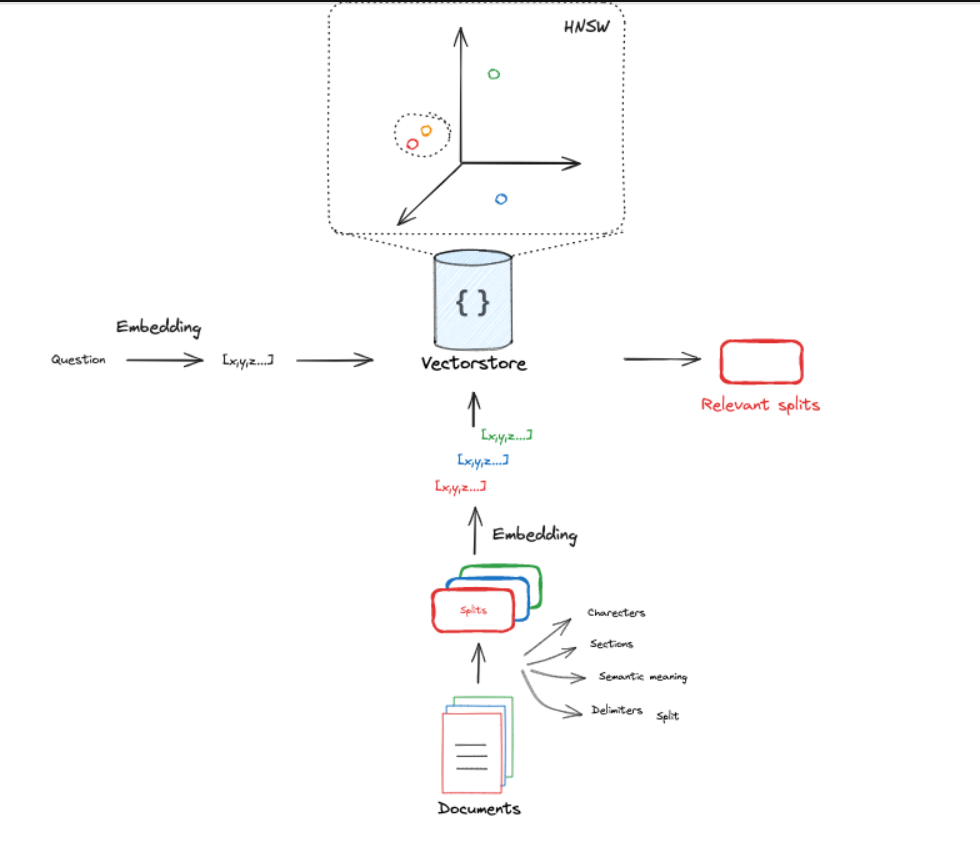

In [ ]:
# Documents
question = "What kinds of pets do I like?"
document = "My favorite pet is a cat."

[Count tokens](https://github.com/openai/openai-cookbook/blob/main/examples/How_to_count_tokens_with_tiktoken.ipynb) considering [~4 char / token](https://help.openai.com/en/articles/4936856-what-are-tokens-and-how-to-count-them)

In [ ]:
import tiktoken

def num_tokens_from_string(string: str, encoding_name: str) -> int:
    """Returns the number of tokens in a text string."""
    encoding = tiktoken.get_encoding(encoding_name)
    num_tokens = len(encoding.encode(string))
    return num_tokens

num_tokens_from_string(question, "cl100k_base")

8

[Text embedding models](https://python.langchain.com/docs/integrations/text_embedding/openai)

In [ ]:
from langchain_openai import OpenAIEmbeddings
embd = OpenAIEmbeddings()
query_result = embd.embed_query(question)
document_result = embd.embed_query(document)
len(query_result)

1536

query_result değişkeni, içinde 1536 adet ondalıklı sayı içeren bir Python listesidir (örneğin: [0.012, -0.045, 0.008, ...] gibi).

Bu 1536 farklı sayı, verdiğiniz metnin anlamsal özelliklerini (anlamını, bağlamını) çok boyutlu bir uzayda temsil eder.

[Cosine similarity](https://platform.openai.com/docs/guides/embeddings/frequently-asked-questions) is recommended (1 indicates identical) for OpenAI embeddings.

Kosinüs benzerliği, iki vektör arasındaki açının kosinüs değerini ölçer. RAG sistemlerinde kullanılmasının temel nedenleri şunlardır:


*   Metinlerin vektör gösterimlerinde (embeddings), vektörün yönü kelimelerin taşıdığı anlamı/konuyu, vektörün uzunluğu (büyüklüğü) ise genellikle metnin uzunluğunu veya kelime frekansını temsil eder. Kosinüs benzerliği vektör boyunu büyüklüğüne bölerek (normalize ederek) sadece yön karşılaştırması yapar. Bu sayede 3 kelimelik bir soru ile 100 kelimelik bir paragraf aynı anlamı taşıyorsa aralarındaki benzerlik yüksek çıkar.

*   [-1, 1] Arasında Değer Alması (Normalize Olması):

1.  1: İki vektör aynı yöne bakıyor (Anlamları tamamen aynı / çok benzer).

2.  0: Vektörler dik (Birbiriyle ilişkisiz konular).

3. -1: Vektörler zıt yöne bakıyor (Zıt anlamlılar). Bu durum benzerlik eşik değerleri (threshold) belirlemeyi son derece kolaylaştırır.





İki metnin doğrudan kelime kelime eşleşmesine (BM25 vb.) bakmak yerine, anlamsal uzaydaki kosinüs açısına bakmak, kullanıcının soru sorarken dokümandaki birebir aynı kelimeleri kullanmasa bile (eş anlamlı kelimeler veya farklı cümle yapıları kullansa dahi) doğru bilgiye ulaşmasını sağlar.

Kosinüs benzerliği iki vektör arasındaki benzerliğe bakar.

Kullanıcının sisteme yazdığı soru (örneğin: "What is Task Decomposition?") embedding modeli (OpenAIEmbeddings) aracılığıyla bir vektöre dönüştürülür.
Kod Karşılığı:

*   query_result = embedding.embed_query("What is Task Decomposition?")


Veri tabanına kaydedilmiş olan blog yazısı, PDF veya makaleden bölünmüş olan her bir metin parçası (chunk) yine aynı embedding modeli ile bir vektöre dönüştürülür.

*   Kod Karşılığı: document_result = embedding.embed_query("Hi! I'm Lilian...")

Sistem, sorgunun vektörü ile veri tabanındaki tüm doküman parçalarının vektörleri arasındaki kosinüs benzerliğini tek tek veya indekslenmiş matrisler üzerinden hesaplar. Kosinüs değeri 1'e en yakın (açısı en küçük) olan doküman parçalarını "Soruyla en alakalı metinler" olarak seçip LLM'e (Büyük Dil Modeline) bağlam (context) olarak gönderir.

In [ ]:
import numpy as np

def cosine_similarity(vec1, vec2):
    dot_product = np.dot(vec1, vec2)
    norm_vec1 = np.linalg.norm(vec1)
    norm_vec2 = np.linalg.norm(vec2)
    return dot_product / (norm_vec1 * norm_vec2)

similarity = cosine_similarity(query_result, document_result)
print("Cosine Similarity:", similarity)

Cosine Similarity: 0.880691583503541


[Document Loaders](https://python.langchain.com/docs/integrations/document_loaders/)

In [ ]:
#### INDEXING ####

# Load blog
import bs4
from langchain_community.document_loaders import WebBaseLoader
loader = WebBaseLoader(
    web_paths=("https://lilianweng.github.io/posts/2023-06-23-agent/",),
    bs_kwargs=dict(
        parse_only=bs4.SoupStrainer(
            class_=("post-content", "post-title", "post-header")
        )
    ),
)
blog_docs = loader.load()

[Splitter](https://python.langchain.com/docs/modules/data_connection/document_transformers/recursive_text_splitter)

Bu metin ayırıcı, genel metinler için önerilen yöntemdir. Bir karakter listesiyle parametrelendirilir. Parçalar (chunk) yeterince küçülene kadar bu karakterleri sırayla kullanarak bölmeye çalışır. Varsayılan liste ["\n\n", "\n", " ", ""] şeklindedir. Bu liste; tüm paragrafları (ardından cümleleri ve sonra sözcükleri) mümkün olduğunca bir arada tutma etkisine sahiptir, çünkü genel olarak anlamsal açıdan birbirine en güçlü bağlı parçaların bunlar olduğu kabul edilir.

In [ ]:
# Split
from langchain_text_splitters import RecursiveCharacterTextSplitter
text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    chunk_size=300,
    chunk_overlap=50)

# Make splits
splits = text_splitter.split_documents(blog_docs)

[Vectorstores](https://python.langchain.com/docs/integrations/vectorstores/)

Vektör Depolama şunu yapar: Metinleri harf olarak değil, taşıdıkları anlamların sayısal haritası (Vektör / Embedding) olarak saklar.

Gerçek Hayat Analojisi (Kütüphane Haritası): Düşünün ki kütüphanedeki her kitaba 1536 adet özellik puanı veriyorsunuz (Ekşilik, Tatlılık, Tarih, Teknoloji vb.).

"Elma" $\rightarrow$ [0.85, 0.12, 0.04, ...]
"Armut" $\rightarrow$ [0.82, 0.15, 0.02, ...]
"Bilgisayar" $\rightarrow$ [0.01, 0.95, 0.88, ...]

Siz kütüphaneciye "bana tatlı ve meyvemsi bir şey ver" dediğinizde, kütüphaneci harf araması yapmaz; aradığınız kavramın koordinatlarına en yakın konumda duran kitapları (Elma ve Armut) bulup getirir.

Chroma (Vektör Veri Tabanı - Vector Store): Metinlerin ve onların vektör karşılıklarının saklandığı özel bir kütüphanedir. WHERE şartı yerine "En Benzer İlk N Tane Parçayı Getir" (k=4) gibi en yakın komşu araması (Nearest Neighbor Search) yapar.


Sadece basit bir matris (Python'daki NumPy dizisi gibi) değildir. Bir matristen çok daha gelişmiştir:

İndeksleme Algoritmaları Var: Eğer 1 milyon tane vektörünüz varsa, sorduğunuz soruyu 1 milyon vektörle tek tek karşılaştırmak çok yavaş olurdu. Chroma, vektörleri uzayda kümeleyerek (HNSW gibi algoritmalarla) sorguyu saniyenin binde birinde doğru kümeye yönlendirir.
Metadata (Meta veri) Saklar: Sadece sayı dizisi saklamaz; o sayının hangi metin parçasına ("Task decomposition is..."), hangi dosyaya ("blog_post.pdf"), hangi sayfaya ait olduğunu da yanında saklar.

Doğru Yöntem: "Metadata (Etiketleme)" Kullanımı
Tüm PDF'leri tek bir havaza (Chroma) atarken her bir metin parçasına "Kendi etiketini" (Metadata) yapıştırırız.

Nasıl Çalışır? Bir PDF'i parçalara böldüğünüzde Chroma'ya şöyle kaydolur:

Metin: "Kullanıcı sözleşmesi 3. maddeye göre..."
Vektör: [0.12, 0.88, ...]
Metadata (Kimlik Bilgisi): {"source": "sozlesme.pdf", "page": 4}
Bu etiketleme sayesinde tek bir Chroma matrisinde 3 harika esnekliğe sahip olursunuz:

Genel Arama: Kullanıcı soru sorar, sistem 10 PDF'in tamamını tarayıp en alakalı cevabı getirir.
Filtreli Arama (PDF Özelinde): Kullanıcı "Sadece sozlesme.pdf içinde ara" derse, Chroma etiket filtreleme (filter={"source": "sozlesme.pdf"}) ile matrisin sadece o PDF'e ait parçalarını saniyeler içinde süzüp arama yapar.
Kaynak Gösterme: Cevap verirken "Bu bilgi rapor_2024.pdf sayfa 12'den alındı" diyebilirsiniz.

ÖRNEK BİR KOD

```
from langchain_community.document_loaders import PyPDFLoader
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import Chroma
from langchain_openai import OpenAIEmbeddings
pdf_dosyalari = ["rapor1.pdf", "sozlesme.pdf", "fatura.pdf"]
hepsinin_parcalari = []
# 1. Bütün PDF'leri tek tek yükleyip parçalıyoruz
for pdf_yolu in pdf_dosyalari:
    loader = PyPDFLoader(pdf_yolu)
    docs = loader.load() # Yüklerken LangChain otomatik kaynak (metadata) etiketini ekler
    
    splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)
    parcalar = splitter.split_documents(docs)
    
    hepsinin_parcalari.extend(parcalar)
# 2. Hepsini TEK BİR Chroma matrisine yüklüyoruz
vectorstore = Chroma.from_documents(
    documents=hepsinin_parcalari,
    embedding=OpenAIEmbeddings(),
    persist_directory="./my_chroma_db" # Diske kaydedip ileride tekrar kullanmak için
)
# 3. İster tüm PDF'lerde ara:
retriever_hepsi = vectorstore.as_retriever()
# 4. İster SADECE "sozlesme.pdf" içinde ara (Metadata Filtresi ile):
retriever_sozlesme = vectorstore.as_retriever(
    search_kwargs={'filter': {'source': 'sozlesme.pdf'}}
)
```



In [ ]:
# Index
from langchain_openai import OpenAIEmbeddings
from langchain_community.vectorstores import Chroma
vectorstore = Chroma.from_documents(documents=splits,
                                    embedding=OpenAIEmbeddings())

retriever = vectorstore.as_retriever()

## **Retreival**

Retrieval, kelime anlamı olarak "Geri Çağırma", "Bulup Getirme" veya "Bilgi Erişimi" demektir.

Günlük hayattan bir analojiyle anlatalım:

Bir avukatsınız ve müvekkiliniz size karmaşık bir hukuki soru sordu. Hafızanızdaki genel bilgilerle hemen cevap vermek yerine önce kütüphanenize gidip ilgili kanun maddelerini raftan çekip çıkarırsınız (Retrieval). Sonra o maddeleri okuyup müvekkilinize mantıklı bir cevap yazarsınız.İşte RAG (Retrieval-Augmented Generation) mimarisindeki Retrieval aşaması, yapay zekanın (LLM) cevap vermeden önce gidip veri tabanından (Chroma'dan) ilgili belge parçalarını bulup getirme işlemidir.

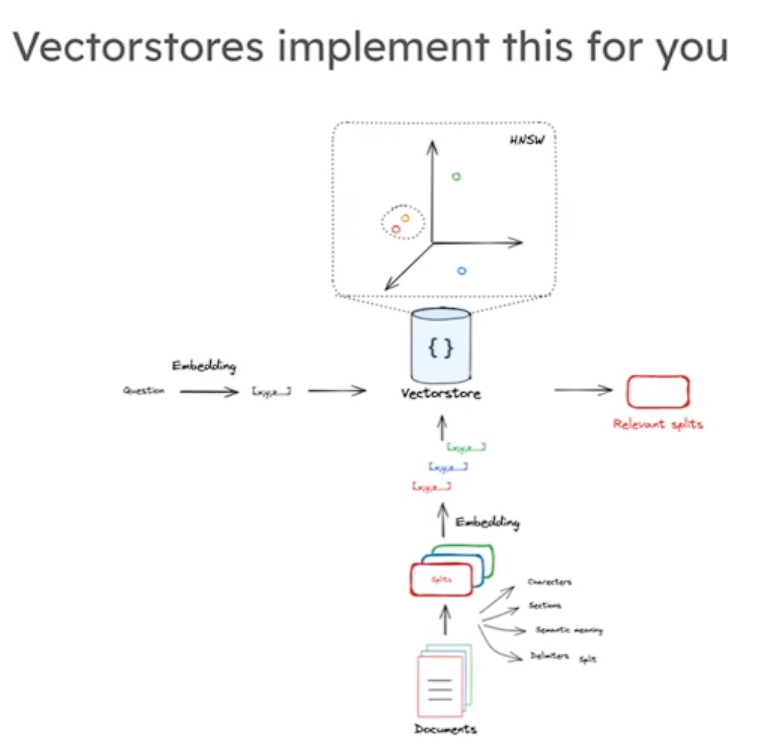

Dökümanlar embedding yapılır vektöre dönüştürülür soru da embedding yapılır vektöre dönüştürülür hepsi bir uzaya yerleştirilir. Üstte kesik çizgilerle gösterilen 3 boyutlu koordinat sistemi (HNSW algoritmasını temsil eder), vektörlerin uzaydaki yerleşimini gösterir. Veri tabanı, sorunun vektörüne uzayda en yakın olan (nokta atışı olarak kesik daire içine alınmış) veri noktalarını arar.

Relevant Splits (İlgili Parçalar): Soruya anlamsal olarak en çok benzeyen ve uzayda ona en yakın olan doküman parçaları seçilerek sonuç olarak döndürülür.

In [ ]:
# Index
from langchain_openai import OpenAIEmbeddings
from langchain_community.vectorstores import Chroma
vectorstore = Chroma.from_documents(documents=splits,
                                    embedding=OpenAIEmbeddings())


retriever = vectorstore.as_retriever(search_kwargs={"k": 1}) # Chroma vektör veri tabanına "Sen artık benim arama ajanım (Retriever) ol" talimatını verir.
#search_kwargs={"k": 1} parametresi ise: "Soru sorduğumda bana kosinüs benzerliği en yüksek olan en alakalı 1 tane (k=1) metin parçasını bulup getir"
#demektir (k=4 yapsaydınız en alakalı 4 parçayı getirirdi).

In [ ]:
docs = retriever.invoke("What is Task Decomposition?") #İlgili bilgiyi fiilen bulup getirme (Retrieval) işlemini yapar.

"""
Arka planda ne çalışır?
Sorduğunuz "What is Task Decomposition?" cümlesini alır.
Bunu bir vektöre (sayı dizisine) dönüştürür.
Chroma içinde kosinüs benzerliği hesaplaması yapar.
En benzer olan doküman parçasını veri tabanından çekip alır ve docs değişkenine atar.

"""

'\nArka planda ne çalışır?\nSorduğunuz "What is Task Decomposition?" cümlesini alır.\nBunu bir vektöre (sayı dizisine) dönüştürür.\nChroma içinde kosinüs benzerliği hesaplaması yapar.\nEn benzer olan doküman parçasını veri tabanından çekip alır ve docs değişkenine atar.\n\n'

LangSmıthden de bakabiliriz çıktıya

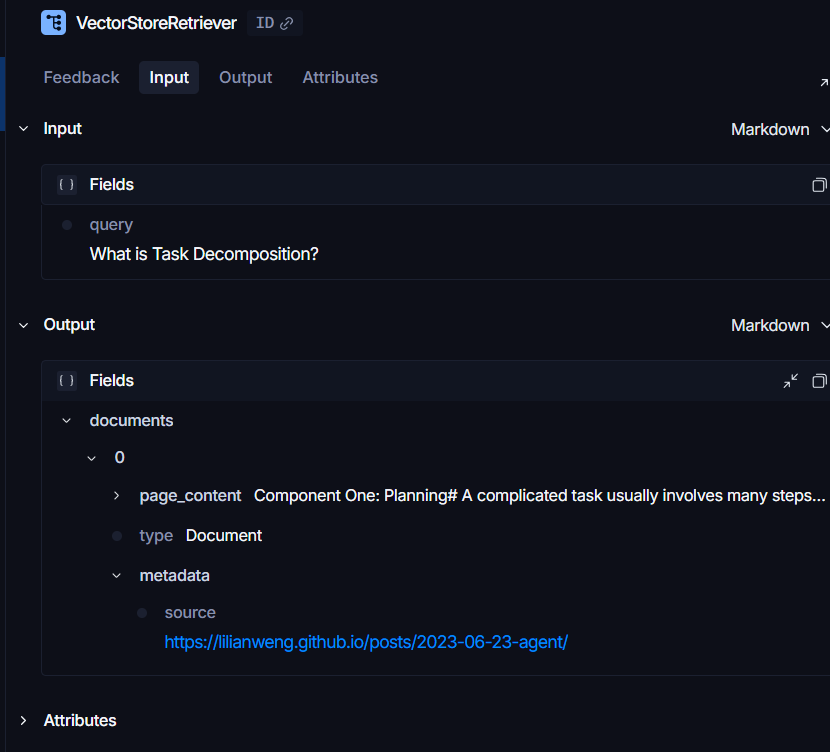

In [ ]:
print(docs[0].page_content)

Component One: Planning#
A complicated task usually involves many steps. An agent needs to know what they are and plan ahead.
Task Decomposition#
Chain of thought (CoT; Wei et al. 2022) has become a standard prompting technique for enhancing model performance on complex tasks. The model is instructed to “think step by step” to utilize more test-time computation to decompose hard tasks into smaller and simpler steps. CoT transforms big tasks into multiple manageable tasks and shed lights into an interpretation of the model’s thinking process.
Tree of Thoughts (Yao et al. 2023) extends CoT by exploring multiple reasoning possibilities at each step. It first decomposes the problem into multiple thought steps and generates multiple thoughts per step, creating a tree structure. The search process can be BFS (breadth-first search) or DFS (depth-first search) with each state evaluated by a classifier (via a prompt) or majority vote.
Task decomposition can be done (1) by LLM with simple prompt

In [ ]:
len(docs)

1

## Generation Code

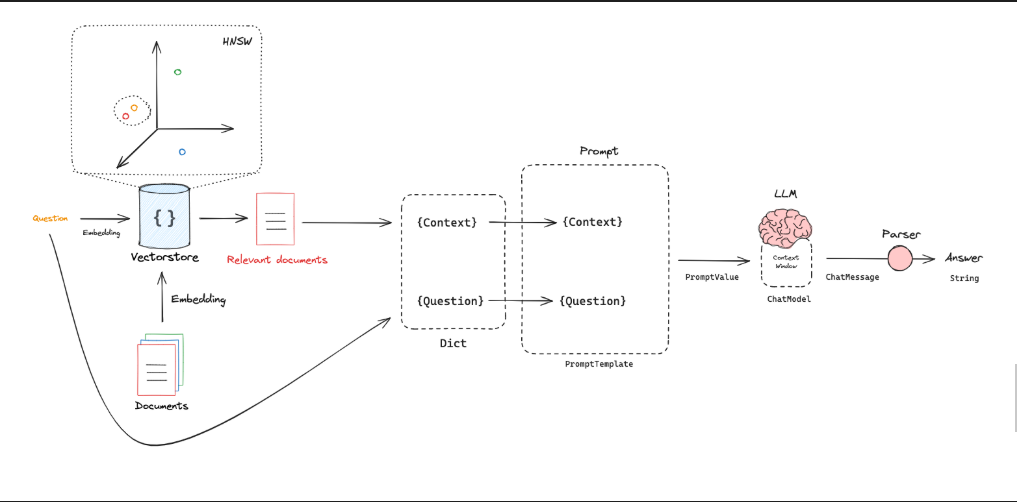

Veri tabanından çekilen bu İlgili Parçalar (Relevant splits), senin orijinal sorunla birlikte birleştirilerek Büyük Dil Modelinin (LLM) "bağlam penceresine" gönderilir. Buradaki beyin simgesi, kullandığın yapay zeka modelini (GPT, Llama, Claude vb.) temsil eder. Bağlam penceresi ise modelin o anlık okuyabildiği ve işleyebildiği "kısa süreli hafızasıdır".

Answer (Cevap): Yapay zeka modeli, kendi başına tahmin yürütmek yerine senin veri tabanından çıkarıp hafızasına (bağlam penceresine) koyduğun bu gerçek metinleri okur. Analizini bu metinler üzerinden yaparak sana tamamen doğrulanmış, nihai bir Cevap üretir.

LangChain kütüphanesinden OpenAI yapay zeka modelini (ChatOpenAI) ve şablon oluşturucuyu (ChatPromptTemplate) kodumuza çağırıyoruz.
template (Metin Şablonu): Yapay zekaya verilecek "Kurallar ve Sınav Kağıdı" metnini hazırlıyoruz.

{context}: Buraya daha sonra Chroma'dan bulduğumuz ilgili doküman parçası gelecek (Değişken alanı).

{question}: Buraya kullanıcının sorduğu soru gelecek (Değişken alanı).

In [ ]:
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate

# Prompt
template = """Answer the question based only on the following context:
{context}

Question: {question}
"""

#Düz yazı halindeki bu metni, LangChain'in anlayabileceği akıllı bir şablon nesnesine dönüştürüyoruz.
prompt = ChatPromptTemplate.from_template(template)
prompt

ChatPromptTemplate(input_variables=['context', 'question'], input_types={}, partial_variables={}, messages=[HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['context', 'question'], input_types={}, partial_variables={}, template='Answer the question based only on the following context:\n{context}\n\nQuestion: {question}\n'), additional_kwargs={})])

Soruyu okuyup cevabı Türkçe/İngilizce olarak yazacak olan büyük dil modelini (OpenAI GPT-3.5) tanımlar.temperature=0: Yapay zekanın "yaratıcılık / uydurma" seviyesidir. 0 yapmak, onun uydurmasını engeller; sadece verilen metne sadık kalmasını sağlar.

In [ ]:
# LLM
llm = ChatOpenAI(model_name="gpt-3.5-turbo", temperature=0)

"Önce verilen bilgileri ve soruyu alıp prompt (şablon) içine yerleştir, oluşan bu dolu şablonu doğrudan llm (GPT modeline) gönder!"
Bu yapı RAG'in en basit 2 adımlı montaj hattıdır.

In [ ]:
# Chain
chain = prompt | llm

In [ ]:
# Run
chain.invoke({"context":docs,"question":"What is Task Decomposition?"})

AIMessage(content='Task Decomposition is a technique used by agents to break down complex tasks into smaller and simpler steps, allowing for better planning and execution. It can be achieved through methods such as Chain of Thought and Tree of Thoughts, which involve breaking down tasks into manageable steps and exploring multiple reasoning possibilities at each step. Task decomposition can also be done using simple prompting, task-specific instructions, or with human inputs.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 79, 'prompt_tokens': 315, 'total_tokens': 394, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-E4uy84E2AcDv0V8QxJbrSQDqwBfny', 'se

In [ ]:
from langsmith import Client

client = Client()
prompt_hub_rag = client.pull_prompt("rlm/rag-prompt", dangerously_pull_public_prompt=True)


İnternetten (LangChain Hub) hazır bir talimat şablonu (prompt) indirir.
Analoji: Yapay zekaya verilecek "Sınav Kağıdı Formatı"dır.
Şablonun İçinde Aslında Ne Yazar?

"Sen bir asistansın. Aşağıda sana verilen [Bağlam / Metin] bilgilerini oku. Bu bilgilere dayanarak kullanıcının sorduğu [Soru] için cevap üret. Eğer cevabı bilmiyorsan bilmediğini söyle, uydurma."

In [ ]:
prompt_hub_rag

ChatPromptTemplate(input_variables=['context', 'question'], input_types={}, partial_variables={}, metadata={'lc_hub_owner': 'rlm', 'lc_hub_repo': 'rag-prompt', 'lc_hub_commit_hash': '50442af133e61576e74536c6556cefe1fac147cad032f4377b60c436e6cdcb6e'}, messages=[HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['context', 'question'], input_types={}, partial_variables={}, template="You are an assistant for question-answering tasks. Use the following pieces of retrieved context to answer the question. If you don't know the answer, just say that you don't know. Use three sentences maximum and keep the answer concise.\nQuestion: {question} \nContext: {context} \nAnswer:"), additional_kwargs={})])

Answer the question based only on the following context: "Task decomposition is a key component... [Chroma'dan gelen metinler (docs)]"

Question: "What is Task Decomposition?"

[RAG chains](https://python.langchain.com/docs/expression_language/get_started#rag-search-example)

In [ ]:
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough

rag_chain = (
    {"context": retriever, "question": RunnablePassthrough()}
    #question: Kullanıcının sorduğu soruyu olduğu gibi geçer (RunnablePassthrough() = "Değiştirmeden aynen aktar").
    #context: Soruyu alır, önce retriever ile Chroma'dan ilgili dokümanları bulur, sonra format_docs ile bu dokümanları birleştirip metin yapar.
    | prompt #Hazırlanan bu paket (context ve question), 1. adımda indirdiğimiz talimat şablonunun içine yerleştirilir.
    | llm #Şablonla doldurulmuş nihai metin GPT-3.5 modeline gönderilir. GPT modeli metni okur ve cevabı üretir.
    | StrOutputParser() #Sadece düz yazı (String) olarak cevabı bırakır.
)

rag_chain.invoke("What is Task Decomposition?") #Tüm bu bant sistemini düğmeye basıp çalıştırır!

'Task Decomposition is a technique used by agents to break down complex tasks into smaller and simpler steps, allowing for better planning and execution. It can be achieved through methods such as Chain of Thought and Tree of Thoughts, which involve breaking down tasks into manageable steps and exploring multiple reasoning possibilities at each step. Task decomposition can also be done using simple prompting, task-specific instructions, or with human inputs.'